In [362]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11



mu0 = 4 * np.pi * 1e-7  # vacuum permeability [T m / A]

# ============================================================
# Best current geometry from diagnostic sweep
# ============================================================

WIRE_THETA_DEG = -5.0

WIRE_X0_UM = 20.0
WIRE_Y0_UM = 0.0

EFFECTIVE_HEIGHT_UM = 20.0

WIRE_LENGTH_UM = 500.0
WIRE_RADIUS_UM = 10.0

# Curved-wire parameters
WIRE_CENTER_RAISE_UM = 10.0
WIRE_SIDE_BOW_UM = 1.0

# Keep current fixed for now
I_POS_mA = +2.0
I_NEG_mA = -2.0
I_POS_A = I_POS_mA * 1e-3
I_NEG_A = I_NEG_mA * 1e-3

# Keep this because diagnostics show signs are correct
SENSOR_Z_SIGN = -1.0

N_POLYLINE_SEGMENTS = 600
# Sampling resolution for the finite cylindrical volume model
N_CYLINDER_LENGTH = 300
N_CYLINDER_CROSS = 9

# Plotting labels and diverging colormap for B field components
B_COMPONENTS = ["Bx", "By", "Bz"]
CMAP = "seismic"

# ============================================================
# Optional local kink model
# ============================================================
# This creates a local sideways displacement of the wire.
# It can generate a stronger local By without making the whole wire
# unrealistically bowed.

USE_LOCAL_KINK = True

WIRE_KINK_AMPLITUDE_UM = 15.0
WIRE_KINK_WIDTH_UM = 100.0
WIRE_KINK_CENTER_UM = 0.0

In [363]:
#Load B_results.csvn+ metadata

B_RESULTS_CSV_PATH = "B_results.csv"

B_df = pd.read_csv(B_RESULTS_CSV_PATH)
B_df = B_df.sort_values(["row", "col"]).reset_index(drop=True)

grid_size = int(np.sqrt(len(B_df)))
if grid_size * grid_size != len(B_df):
    raise ValueError("B_results.csv does not contain a square grid.")

x_grid_um = B_df["x_um"].to_numpy().reshape(grid_size, grid_size)
y_grid_um = B_df["y_um"].to_numpy().reshape(grid_size, grid_size)

extent_um = [
    np.nanmin(x_grid_um),
    np.nanmax(x_grid_um),
    np.nanmin(y_grid_um),
    np.nanmax(y_grid_um),
]

B_pos_meas = np.stack([
    B_df["Bx_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_pos_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_neg_meas = np.stack([
    B_df["Bx_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_neg_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_odd_meas = np.stack([
    B_df["Bx_odd_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_odd_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_odd_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_even_meas = np.stack([
    B_df["Bx_even_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_even_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_even_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)


METADATA_CSV_PATH = "B_results_metadata.csv"

metadata_df = pd.read_csv(METADATA_CSV_PATH)

def get_metadata_value(key, default=None, cast=float):
    matches = metadata_df.loc[metadata_df["key"] == key, "value"]

    if len(matches) == 0:
        print(f"Metadata key '{key}' not found. Using default: {default}")
        return default

    value = matches.iloc[0]

    if cast is None:
        return value

    try:
        return cast(value)
    except Exception:
        print(f"Could not cast metadata key '{key}' = {value}. Using default: {default}")
        return default


PULSE_AMPLITUDE_mV = get_metadata_value("pulse_amplitude_mV", default=10.0, cast=float)
PULSE_AMPLITUDE_V = get_metadata_value("pulse_amplitude_V", default=PULSE_AMPLITUDE_mV * 1e-3, cast=float)

I_POS_mA = get_metadata_value("current_pos_mA", default=2.0, cast=float)
I_NEG_mA = get_metadata_value("current_neg_mA", default=-2.0, cast=float)

I_POS_A = I_POS_mA * 1e-3
I_NEG_A = I_NEG_mA * 1e-3

EFFECTIVE_HEIGHT_UM = get_metadata_value(
    "effective_wire_height_um_for_simulation",
    default=20.0,
    cast=float,
)




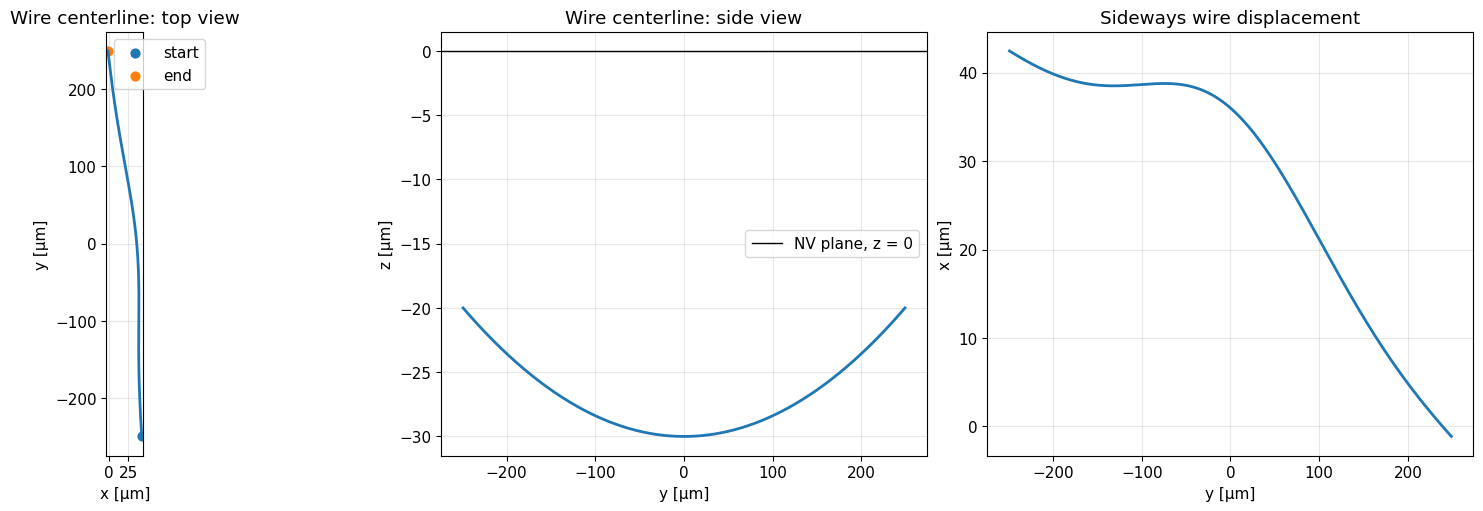

Wire geometry summary
---------------------
x range [µm]: -1.13 to 42.45
y range [µm]: -249.05 to 249.05
z range [µm]: -30.00 to -20.00

Local tangent summary
---------------------
max |tx| = 0.1790
max |ty| = 0.9998
max |tz| = 0.0798

Current settings
----------------
WIRE_THETA_DEG = -5.0
WIRE_CENTER_RAISE_UM = 10.0
WIRE_SIDE_BOW_UM = 1.0
USE_LOCAL_KINK = True
WIRE_KINK_AMPLITUDE_UM = 15.0
WIRE_KINK_CENTER_UM = 0.0
WIRE_KINK_WIDTH_UM = 100.0


In [364]:
# ============================================================
# Curved-wire geometry helper

def make_curved_wire_centerline_um(
    length_um,
    x0_um,
    y0_um,
    height_um,
    theta_deg,
    center_raise_um=0.0,
    side_bow_um=0.0,
    n_points=601,
    sensor_z_sign=-1.0,
    use_local_kink=False,
    kink_amplitude_um=0.0,
    kink_center_um=0.0,
    kink_width_um=60.0,
):
    """
    Create a 3D curved wire centerline.

    Parameters
    ----------
    length_um:
        Total modeled wire length.

    x0_um, y0_um:
        Approximate center of the wire in the image plane.

    height_um:
        Base wire-to-NV-layer distance.

    theta_deg:
        In-plane tilt angle.
        theta = 0 means wire/current mostly along +y.
        theta > 0 tilts toward +x as y increases.

    center_raise_um:
        Positive value raises the middle of the wire farther away
        from the NV layer than the ends.

    side_bow_um:
        Smooth sideways bow in x. Positive shifts the middle toward +x.

    use_local_kink:
        If True, adds a local Gaussian sideways kink in x.

    kink_amplitude_um:
        Size of local kink in x.

    kink_center_um:
        Position of local kink along the nominal wire coordinate s.

    kink_width_um:
        Width of local kink.

    Returns
    -------
    wire_xyz_um:
        Array with shape (n_points, 3), columns [x, y, z] in µm.
    """

    theta = np.deg2rad(theta_deg)

    # Coordinate along nominal wire axis
    s_um = np.linspace(-length_um / 2, length_um / 2, n_points)

    # Normalized coordinate: -1 at one end, +1 at the other end
    t = 2.0 * s_um / length_um

    # Smooth parabola profile:
    # 0 at ends, 1 at middle
    bow_profile = 1.0 - t**2
    bow_profile = np.maximum(bow_profile, 0.0)

    # Straight tilted wire in xy
    x_straight_um = x0_um + s_um * np.sin(theta)
    y_straight_um = y0_um + s_um * np.cos(theta)

    # Smooth global sideways bow
    x_wire_um = x_straight_um + side_bow_um * bow_profile

    # Optional local sideways kink
    if use_local_kink:
        if kink_width_um <= 0:
            raise ValueError("kink_width_um must be positive.")

        kink_profile = np.exp(
            -0.5 * ((s_um - kink_center_um) / kink_width_um) ** 2
        )

        x_wire_um = x_wire_um + kink_amplitude_um * kink_profile

    y_wire_um = y_straight_um

    # Vertical arch:
    # ends at height_um, middle at height_um + center_raise_um
    z_distance_um = height_um + center_raise_um * bow_profile

    # Apply simulation z convention
    z_wire_um = sensor_z_sign * z_distance_um

    wire_xyz_um = np.column_stack([
        x_wire_um,
        y_wire_um,
        z_wire_um,
    ])

    return wire_xyz_um

# ============================================================
# Check the exact 3D curved wire geometry used for simulation
# ============================================================

wire_xyz_um = make_curved_wire_centerline_um(
    length_um=WIRE_LENGTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    height_um=EFFECTIVE_HEIGHT_UM,
    theta_deg=WIRE_THETA_DEG,
    center_raise_um=WIRE_CENTER_RAISE_UM,
    side_bow_um=WIRE_SIDE_BOW_UM,
    n_points=N_POLYLINE_SEGMENTS + 1,
    sensor_z_sign=SENSOR_Z_SIGN,
    use_local_kink=USE_LOCAL_KINK,
    kink_amplitude_um=WIRE_KINK_AMPLITUDE_UM,
    kink_center_um=WIRE_KINK_CENTER_UM,
    kink_width_um=WIRE_KINK_WIDTH_UM,
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

# Top view: x-y
axes[0].plot(wire_xyz_um[:, 0], wire_xyz_um[:, 1], lw=2)
axes[0].scatter(wire_xyz_um[0, 0], wire_xyz_um[0, 1], label="start", s=40)
axes[0].scatter(wire_xyz_um[-1, 0], wire_xyz_um[-1, 1], label="end", s=40)
axes[0].set_title("Wire centerline: top view")
axes[0].set_xlabel("x [µm]")
axes[0].set_ylabel("y [µm]")
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Side view: y-z
axes[1].plot(wire_xyz_um[:, 1], wire_xyz_um[:, 2], lw=2)
axes[1].axhline(0, color="black", lw=1, label="NV plane, z = 0")
axes[1].set_title("Wire centerline: side view")
axes[1].set_xlabel("y [µm]")
axes[1].set_ylabel("z [µm]")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# x as a function of y
axes[2].plot(wire_xyz_um[:, 1], wire_xyz_um[:, 0], lw=2)
axes[2].set_title("Sideways wire displacement")
axes[2].set_xlabel("y [µm]")
axes[2].set_ylabel("x [µm]")
axes[2].grid(True, alpha=0.3)

plt.show()

# Segment directions: this tells us whether the wire actually has dx/ds and dz/ds
dwire = np.diff(wire_xyz_um, axis=0)
ds = np.linalg.norm(dwire, axis=1)

tx = dwire[:, 0] / ds
ty = dwire[:, 1] / ds
tz = dwire[:, 2] / ds

print("Wire geometry summary")
print("---------------------")
print(f"x range [µm]: {wire_xyz_um[:,0].min():.2f} to {wire_xyz_um[:,0].max():.2f}")
print(f"y range [µm]: {wire_xyz_um[:,1].min():.2f} to {wire_xyz_um[:,1].max():.2f}")
print(f"z range [µm]: {wire_xyz_um[:,2].min():.2f} to {wire_xyz_um[:,2].max():.2f}")

print("\nLocal tangent summary")
print("---------------------")
print(f"max |tx| = {np.max(np.abs(tx)):.4f}")
print(f"max |ty| = {np.max(np.abs(ty)):.4f}")
print(f"max |tz| = {np.max(np.abs(tz)):.4f}")

print("\nCurrent settings")
print("----------------")
print(f"WIRE_THETA_DEG = {WIRE_THETA_DEG}")
print(f"WIRE_CENTER_RAISE_UM = {WIRE_CENTER_RAISE_UM}")
print(f"WIRE_SIDE_BOW_UM = {WIRE_SIDE_BOW_UM}")
print(f"USE_LOCAL_KINK = {USE_LOCAL_KINK}")
print(f"WIRE_KINK_AMPLITUDE_UM = {WIRE_KINK_AMPLITUDE_UM}")
print(f"WIRE_KINK_CENTER_UM = {WIRE_KINK_CENTER_UM}")
print(f"WIRE_KINK_WIDTH_UM = {WIRE_KINK_WIDTH_UM}")

## wire models biot approx and cylindrical wire 2 functions


SI units internally:
   x,y,z in meters
   I in amperes
   B in tesla 
 Output:  B in nT


In [365]:
#helper fucntiosn to bend that bitch

def bent_wire_height_um(s_um, base_height_um, length_um, center_raise_um):
    parabola = 1.0 - (2.0 * s_um / length_um)**2
    parabola = np.maximum(parabola, 0.0)
    return base_height_um + center_raise_um * parabola

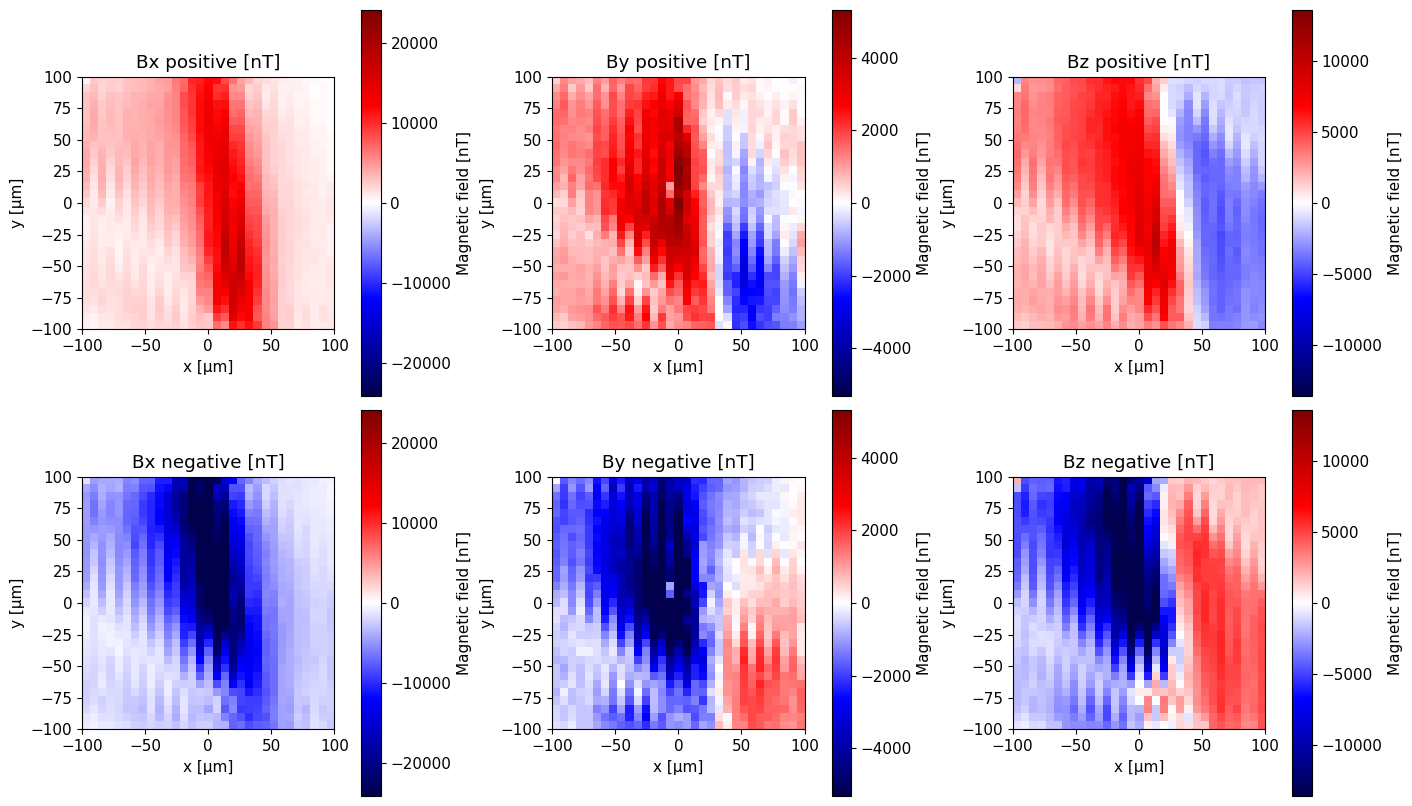

In [366]:


fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
for i, comp in enumerate(B_COMPONENTS):
    pos_map = B_pos_meas[i]
    neg_map = B_neg_meas[i]

    lim = max(
        np.nanpercentile(np.abs(pos_map), 95),
        np.nanpercentile(np.abs(neg_map), 95),
    )

    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im0 = axes[0, i].imshow(
        pos_map,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[0, i].set_title(f"{comp} positive [nT]")
    axes[0, i].set_xlabel("x [µm]")
    axes[0, i].set_ylabel("y [µm]")
    plt.colorbar(im0, ax=axes[0, i], label="Magnetic field [nT]")

    im1 = axes[1, i].imshow(
        neg_map,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[1, i].set_title(f"{comp} negative [nT]")
    axes[1, i].set_xlabel("x [µm]")
    axes[1, i].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[1, i], label="Magnetic field [nT]")

plt.show()

In [367]:


# ============================================================
# Approximation 1:
# Thin curved wire Biot-Savart line integral
# ============================================================
# This treats the wire as an infinitely thin current path.
#
# Each wire segment contributes:
#
#   dB = mu0 / (4 pi) * I * dl x R / |R|^3
#
# Important:
#   dl is computed from the actual 3D centerline.
#   Therefore vertical bending gives a real dz current component.
# ============================================================

def simulate_curved_wire_biot_savart_line(
    x_um,
    y_um,
    I_A,
    length_um,
    x0_um,
    y0_um,
    height_um,
    theta_deg,
    center_raise_um=0.0,
    side_bow_um=0.0,
    n_segments=600,
    sensor_z_sign=-1.0,
    use_local_kink=False,
    kink_amplitude_um=0.0,
    kink_center_um=0.0,
    kink_width_um=60.0,
):
    """
    Simulate magnetic field from a thin 3D curved wire.

    Output
    ------
    B_nT:
        Array with shape (3, Ny, Nx), ordered as [Bx, By, Bz].
    """

    # Observation points in meters
    X = x_um * 1e-6
    Y = y_um * 1e-6
    Z = np.zeros_like(X)

    # Wire centerline in µm, then meters
    wire_xyz_um = make_curved_wire_centerline_um(
        length_um=length_um,
        x0_um=x0_um,
        y0_um=y0_um,
        height_um=height_um,
        theta_deg=theta_deg,
        center_raise_um=center_raise_um,
        side_bow_um=side_bow_um,
        n_points=n_segments + 1,
        sensor_z_sign=sensor_z_sign,
        use_local_kink=use_local_kink,
        kink_amplitude_um=kink_amplitude_um,
        kink_center_um=kink_center_um,
        kink_width_um=kink_width_um,
    )

    wire_xyz_m = wire_xyz_um * 1e-6

    Bx_T = np.zeros_like(X, dtype=float)
    By_T = np.zeros_like(X, dtype=float)
    Bz_T = np.zeros_like(X, dtype=float)

    prefactor = mu0 * I_A / (4.0 * np.pi)

    for k in range(n_segments):
        r1 = wire_xyz_m[k]
        r2 = wire_xyz_m[k + 1]

        # Actual 3D current element
        dl = r2 - r1

        # Midpoint approximation for this segment
        r_mid = 0.5 * (r1 + r2)

        Rx = X - r_mid[0]
        Ry = Y - r_mid[1]
        Rz = Z - r_mid[2]

        R2 = Rx**2 + Ry**2 + Rz**2
        R = np.sqrt(R2)
        R3 = np.where(R < 1e-15, 1e-45, R**3)

        # dl x R
        cross_x = dl[1] * Rz - dl[2] * Ry
        cross_y = dl[2] * Rx - dl[0] * Rz
        cross_z = dl[0] * Ry - dl[1] * Rx

        Bx_T += prefactor * cross_x / R3
        By_T += prefactor * cross_y / R3
        Bz_T += prefactor * cross_z / R3

    B_nT = 1e9 * np.stack([Bx_T, By_T, Bz_T], axis=0)

    return B_nT

# ============================================================
# Helper for finite-cylinder model
# ============================================================
# For each wire segment, we need two perpendicular directions
# spanning the circular cross-section.
# ============================================================

def perpendicular_basis_from_tangent(t_hat):
    """
    Given a unit tangent vector t_hat, return two unit vectors n1 and n2
    perpendicular to t_hat.

    The cross-section plane is spanned by n1 and n2.
    """

    t_hat = np.asarray(t_hat, dtype=float)
    t_hat = t_hat / np.linalg.norm(t_hat)

    # Choose a reference vector that is not parallel to t_hat
    ref = np.array([0.0, 0.0, 1.0])

    if abs(np.dot(t_hat, ref)) > 0.95:
        ref = np.array([1.0, 0.0, 0.0])

    n1 = np.cross(t_hat, ref)
    n1 = n1 / np.linalg.norm(n1)

    n2 = np.cross(t_hat, n1)
    n2 = n2 / np.linalg.norm(n2)

    return n1, n2


def circular_cross_section_offsets_um(radius_um, n_cross):
    """
    Create sampling points inside a circular cross-section.

    Returns
    -------
    offsets:
        Array of shape (N, 2), with coordinates [a, b] in µm.
        These multiply the local perpendicular basis vectors n1 and n2.
    """

    a_values = np.linspace(-radius_um, radius_um, n_cross)
    b_values = np.linspace(-radius_um, radius_um, n_cross)

    offsets = []

    for a in a_values:
        for b in b_values:
            if a**2 + b**2 <= radius_um**2:
                offsets.append((a, b))

    offsets = np.asarray(offsets, dtype=float)

    if len(offsets) == 0:
        raise ValueError("No cross-section points selected. Increase n_cross.")

    return offsets



# ============================================================
# Approximation 2:
# Finite cylindrical curved wire, volume integration
# ============================================================
# This models the wire as a finite-radius tube following the same
# 3D curved centerline.
#
# Each small volume element contributes:
#
#   dB = mu0 / (4 pi) * J dV x R / |R|^3
#
# where:
#   J is along the local tangent of the wire.
#
# This is more physical than the previous finite-cylinder version because:
#   - the current direction follows the curved wire,
#   - vertical bending creates dz current components,
#   - sideways bow/kink creates dx current components,
#   - the finite radius is included by sampling the cross-section.
# ============================================================

def simulate_curved_wire_finite_cylinder_volume(
    x_um,
    y_um,
    I_A,
    length_um,
    radius_um,
    x0_um,
    y0_um,
    height_um,
    theta_deg,
    center_raise_um=0.0,
    side_bow_um=0.0,
    n_segments=300,
    n_cross=9,
    sensor_z_sign=-1.0,
    use_local_kink=False,
    kink_amplitude_um=0.0,
    kink_center_um=0.0,
    kink_width_um=60.0,
):
    """
    Simulate magnetic field from a finite-radius curved cylindrical wire.

    Output
    ------
    B_nT:
        Array with shape (3, Ny, Nx), ordered as [Bx, By, Bz].
    """

    # Observation points in meters
    X = x_um * 1e-6
    Y = y_um * 1e-6
    Z = np.zeros_like(X)

    # Wire centerline
    wire_xyz_um = make_curved_wire_centerline_um(
        length_um=length_um,
        x0_um=x0_um,
        y0_um=y0_um,
        height_um=height_um,
        theta_deg=theta_deg,
        center_raise_um=center_raise_um,
        side_bow_um=side_bow_um,
        n_points=n_segments + 1,
        sensor_z_sign=sensor_z_sign,
        use_local_kink=use_local_kink,
        kink_amplitude_um=kink_amplitude_um,
        kink_center_um=kink_center_um,
        kink_width_um=kink_width_um,
    )

    wire_xyz_m = wire_xyz_um * 1e-6

    # Cross-section sampling
    offsets_um = circular_cross_section_offsets_um(
        radius_um=radius_um,
        n_cross=n_cross,
    )

    radius_m = radius_um * 1e-6
    area_m2 = np.pi * radius_m**2

    # Uniform current density magnitude
    J_A_per_m2 = I_A / area_m2

    # Each cross-section sample represents equal area
    dA_m2 = area_m2 / len(offsets_um)

    Bx_T = np.zeros_like(X, dtype=float)
    By_T = np.zeros_like(X, dtype=float)
    Bz_T = np.zeros_like(X, dtype=float)

    prefactor = mu0 / (4.0 * np.pi)

    for k in range(n_segments):
        r1 = wire_xyz_m[k]
        r2 = wire_xyz_m[k + 1]

        dl_vec = r2 - r1
        ds_m = np.linalg.norm(dl_vec)

        if ds_m == 0:
            continue

        t_hat = dl_vec / ds_m

        # Local cross-section basis
        n1, n2 = perpendicular_basis_from_tangent(t_hat)

        # Segment midpoint
        r_mid = 0.5 * (r1 + r2)

        # Current element integrated over small volume:
        # J dV vector = J * dA * ds * t_hat
        JdV_vec = J_A_per_m2 * dA_m2 * ds_m * t_hat

        for a_um, b_um in offsets_um:
            offset_m = (a_um * 1e-6) * n1 + (b_um * 1e-6) * n2
            source = r_mid + offset_m

            Rx = X - source[0]
            Ry = Y - source[1]
            Rz = Z - source[2]

            R2 = Rx**2 + Ry**2 + Rz**2
            R = np.sqrt(R2)
            R3 = np.where(R < 1e-15, 1e-45, R**3)

            # JdV x R
            cross_x = JdV_vec[1] * Rz - JdV_vec[2] * Ry
            cross_y = JdV_vec[2] * Rx - JdV_vec[0] * Rz
            cross_z = JdV_vec[0] * Ry - JdV_vec[1] * Rx

            Bx_T += prefactor * cross_x / R3
            By_T += prefactor * cross_y / R3
            Bz_T += prefactor * cross_z / R3

    B_nT = 1e9 * np.stack([Bx_T, By_T, Bz_T], axis=0)

    return B_nT

In [368]:
# ============================================================
# Simulate POS and NEG fields with both approximations
# ============================================================

# ----------------------------
# Approximation 1: thin line
# ----------------------------

B_pos_sim_line = simulate_curved_wire_biot_savart_line(
    x_grid_um,
    y_grid_um,
    I_A=I_POS_A,
    length_um=WIRE_LENGTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    height_um=EFFECTIVE_HEIGHT_UM,
    theta_deg=WIRE_THETA_DEG,
    center_raise_um=WIRE_CENTER_RAISE_UM,
    side_bow_um=WIRE_SIDE_BOW_UM,
    n_segments=N_POLYLINE_SEGMENTS,
    sensor_z_sign=SENSOR_Z_SIGN,
    use_local_kink=USE_LOCAL_KINK,
    kink_amplitude_um=WIRE_KINK_AMPLITUDE_UM,
    kink_center_um=WIRE_KINK_CENTER_UM,
    kink_width_um=WIRE_KINK_WIDTH_UM,
)

B_neg_sim_line = simulate_curved_wire_biot_savart_line(
    x_grid_um,
    y_grid_um,
    I_A=I_NEG_A,
    length_um=WIRE_LENGTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    height_um=EFFECTIVE_HEIGHT_UM,
    theta_deg=WIRE_THETA_DEG,
    center_raise_um=WIRE_CENTER_RAISE_UM,
    side_bow_um=WIRE_SIDE_BOW_UM,
    n_segments=N_POLYLINE_SEGMENTS,
    sensor_z_sign=SENSOR_Z_SIGN,
    use_local_kink=USE_LOCAL_KINK,
    kink_amplitude_um=WIRE_KINK_AMPLITUDE_UM,
    kink_center_um=WIRE_KINK_CENTER_UM,
    kink_width_um=WIRE_KINK_WIDTH_UM,
)

# ------------------------------------
# Approximation 2: finite cylinder
# ------------------------------------

B_pos_sim_cylinder = simulate_curved_wire_finite_cylinder_volume(
    x_grid_um,
    y_grid_um,
    I_A=I_POS_A,
    length_um=WIRE_LENGTH_UM,
    radius_um=WIRE_RADIUS_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    height_um=EFFECTIVE_HEIGHT_UM,
    theta_deg=WIRE_THETA_DEG,
    center_raise_um=WIRE_CENTER_RAISE_UM,
    side_bow_um=WIRE_SIDE_BOW_UM,
    n_segments=N_CYLINDER_LENGTH,
    n_cross=N_CYLINDER_CROSS,
    sensor_z_sign=SENSOR_Z_SIGN,
    use_local_kink=USE_LOCAL_KINK,
    kink_amplitude_um=WIRE_KINK_AMPLITUDE_UM,
    kink_center_um=WIRE_KINK_CENTER_UM,
    kink_width_um=WIRE_KINK_WIDTH_UM,
)

B_neg_sim_cylinder = simulate_curved_wire_finite_cylinder_volume(
    x_grid_um,
    y_grid_um,
    I_A=I_NEG_A,
    length_um=WIRE_LENGTH_UM,
    radius_um=WIRE_RADIUS_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    height_um=EFFECTIVE_HEIGHT_UM,
    theta_deg=WIRE_THETA_DEG,
    center_raise_um=WIRE_CENTER_RAISE_UM,
    side_bow_um=WIRE_SIDE_BOW_UM,
    n_segments=N_CYLINDER_LENGTH,
    n_cross=N_CYLINDER_CROSS,
    sensor_z_sign=SENSOR_Z_SIGN,
    use_local_kink=USE_LOCAL_KINK,
    kink_amplitude_um=WIRE_KINK_AMPLITUDE_UM,
    kink_center_um=WIRE_KINK_CENTER_UM,
    kink_width_um=WIRE_KINK_WIDTH_UM,
)

print("Finished simulations.")
print("---------------------")
print("Available simulated fields:")
print("B_pos_sim_line, B_neg_sim_line")
print("B_pos_sim_cylinder, B_neg_sim_cylinder")

Finished simulations.
---------------------
Available simulated fields:
B_pos_sim_line, B_neg_sim_line
B_pos_sim_cylinder, B_neg_sim_cylinder


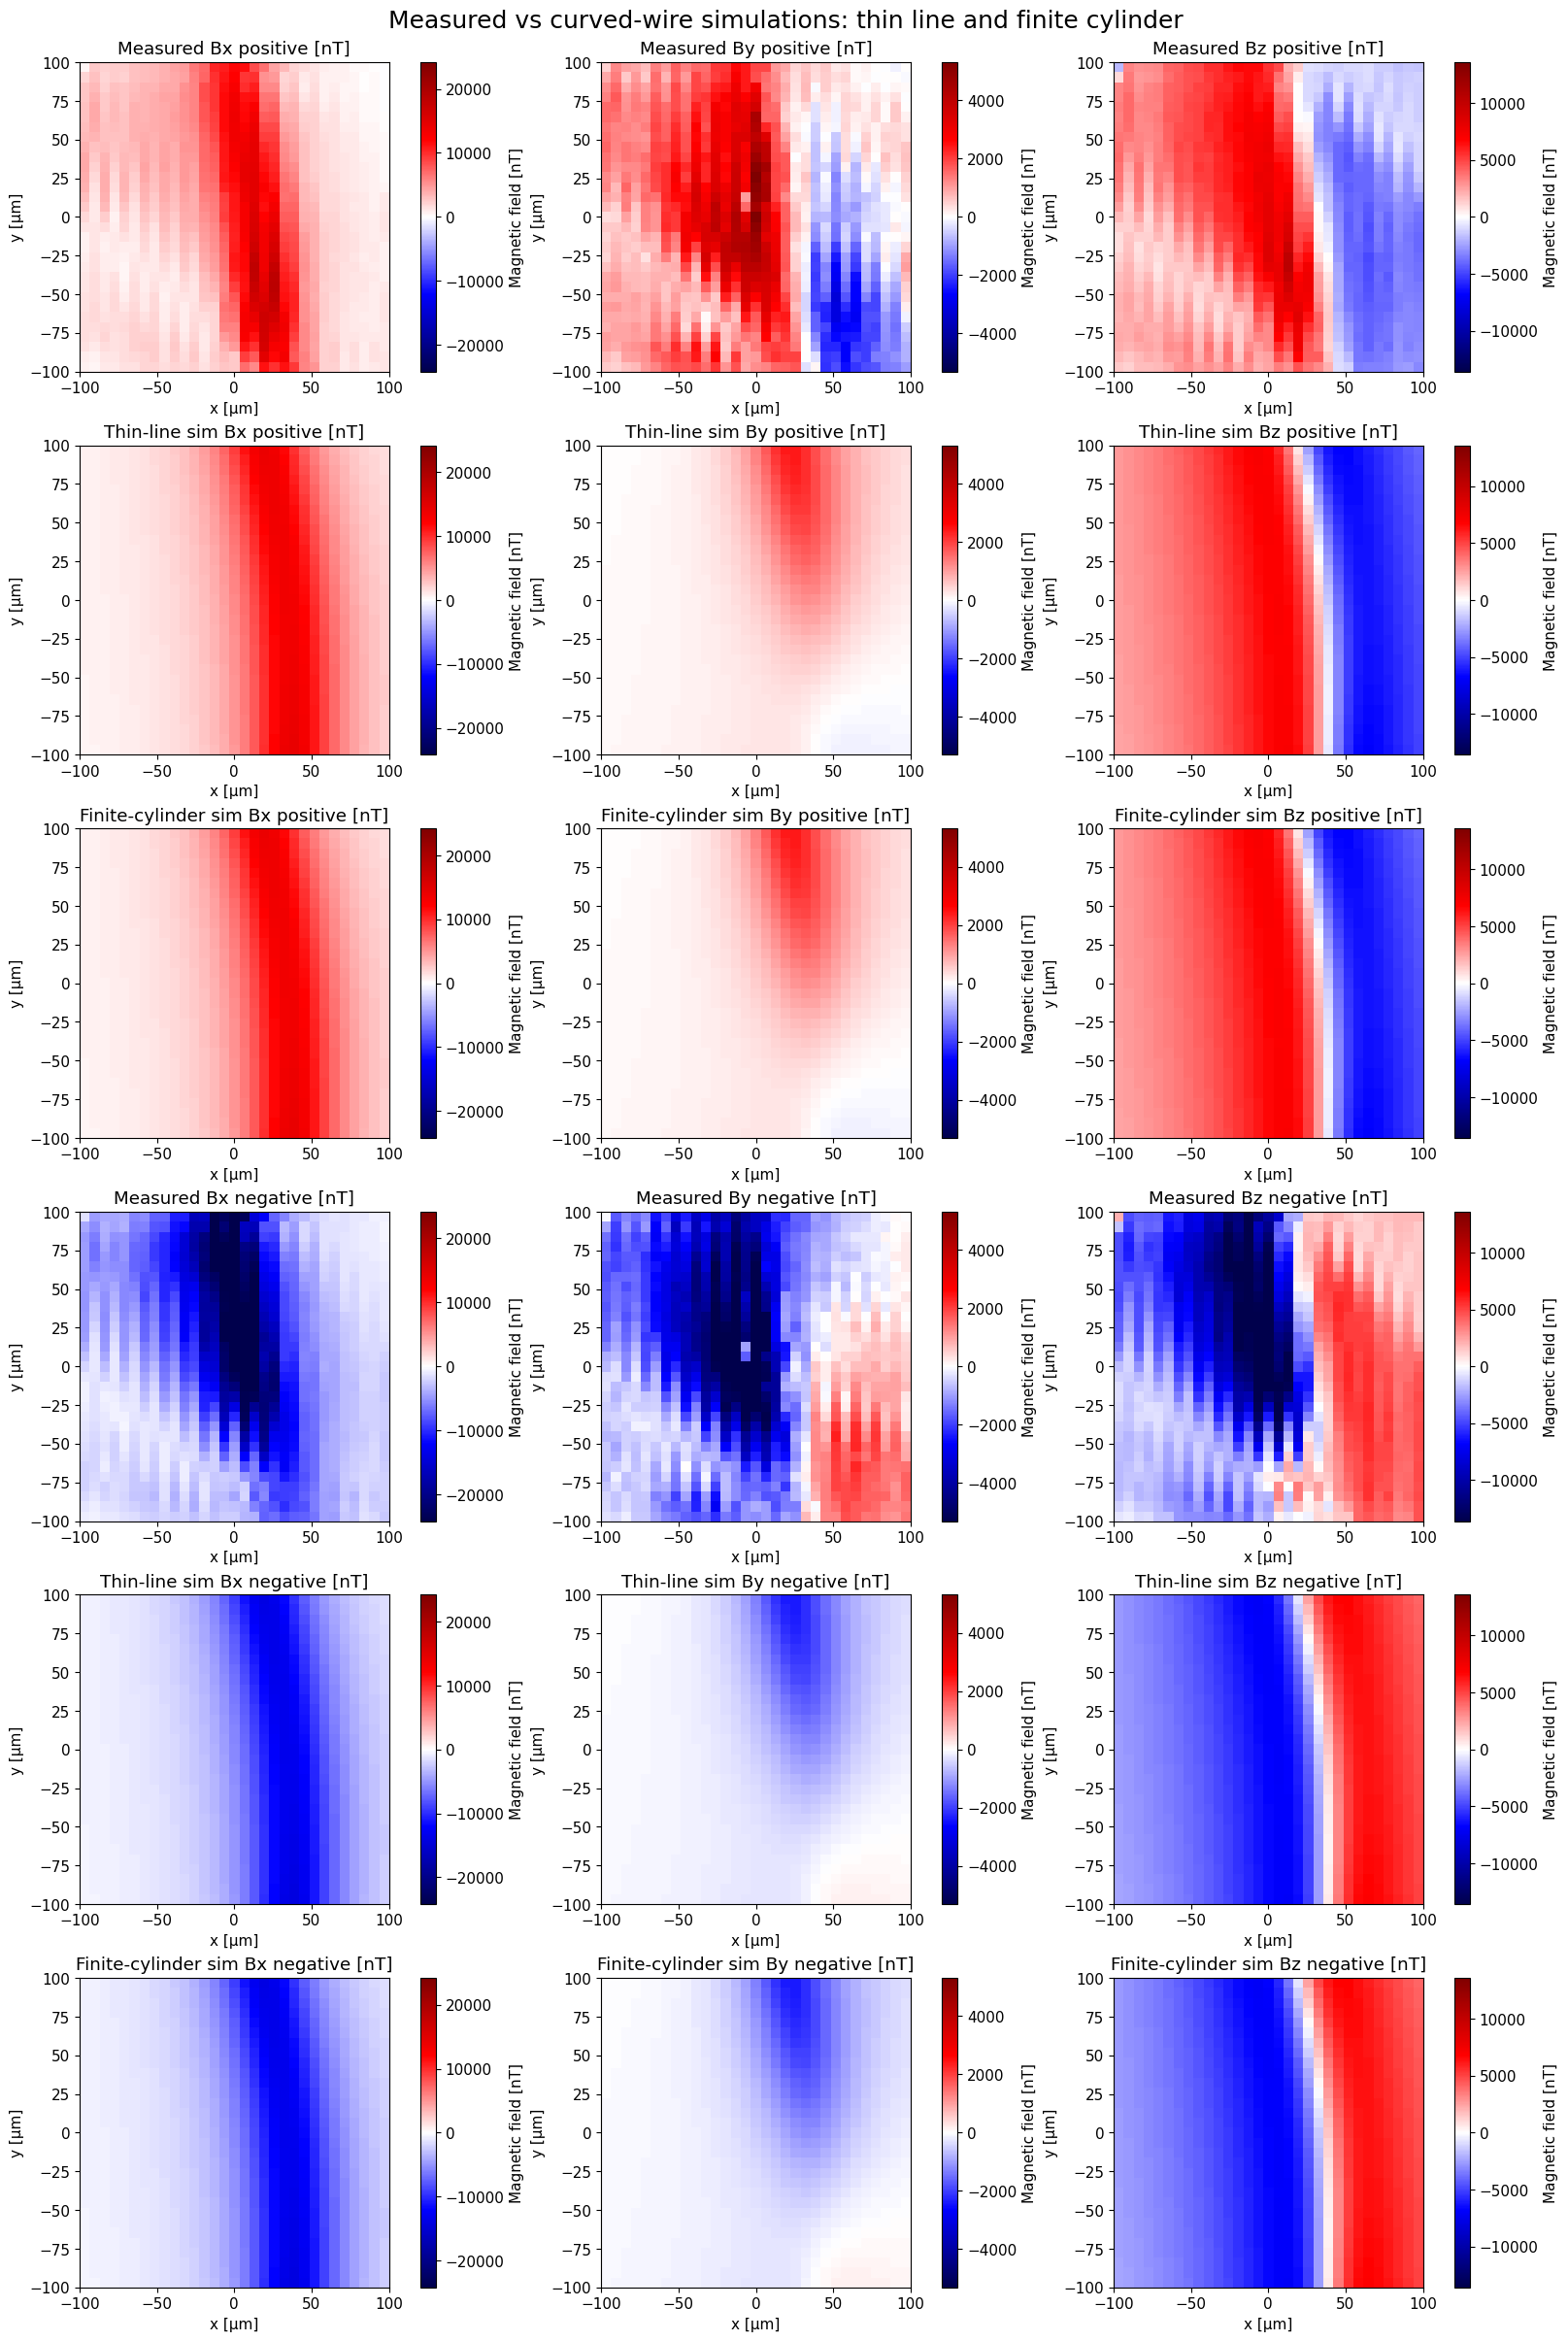

In [369]:
# ============================================================
# Plot measured POS/NEG fields vs both 3D curved-wire approximations
# ============================================================

fig, axes = plt.subplots(6, 3, figsize=(16, 24), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    measured_pos = B_pos_meas[i]
    measured_neg = B_neg_meas[i]
    line_pos = B_pos_sim_line[i]
    line_neg = B_neg_sim_line[i]
    cyl_pos = B_pos_sim_cylinder[i]
    cyl_neg = B_neg_sim_cylinder[i]

    lim = max(
        np.nanpercentile(np.abs(measured_pos), 95),
        np.nanpercentile(np.abs(measured_neg), 95),
        np.nanpercentile(np.abs(line_pos), 95),
        np.nanpercentile(np.abs(line_neg), 95),
        np.nanpercentile(np.abs(cyl_pos), 95),
        np.nanpercentile(np.abs(cyl_neg), 95),
    )

    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    row_maps = [
        (measured_pos, f"Measured {comp} positive [nT]"),
        (line_pos, f"Thin-line sim {comp} positive [nT]"),
        (cyl_pos, f"Finite-cylinder sim {comp} positive [nT]"),
        (measured_neg, f"Measured {comp} negative [nT]"),
        (line_neg, f"Thin-line sim {comp} negative [nT]"),
        (cyl_neg, f"Finite-cylinder sim {comp} negative [nT]"),
    ]

    for row_i, (data, title) in enumerate(row_maps):
        im = axes[row_i, i].imshow(
            data,
            extent=extent_um,
            origin="lower",
            aspect="equal",
            cmap=CMAP,
            vmin=-lim,
            vmax=lim,
        )
        axes[row_i, i].set_title(title)
        axes[row_i, i].set_xlabel("x [µm]")
        axes[row_i, i].set_ylabel("y [µm]")
        plt.colorbar(im, ax=axes[row_i, i], label="Magnetic field [nT]")

fig.suptitle("Measured vs curved-wire simulations: thin line and finite cylinder", fontsize=18)
plt.show()

In [370]:
# ============================================================
# Diagnostic scan: local kink parameters
# ============================================================
# We keep the best smooth-wire parameters from the previous sweep fixed:
#   height = 20 µm
#   center_raise = 10 µm
#   side_bow = 5 µm
#   theta = -5 deg
#
# Then we scan only the local kink.
# ============================================================

base_height_um = 20.0
base_raise_um = 10.0
base_side_bow_um = 5.0
base_theta_deg = -5.0

kink_amplitudes_um = [-25.0, -15.0, -10.0, 0.0, 10.0, 15.0, 25.0]
kink_centers_um = [-100.0, -60.0, -30.0, 0.0, 30.0, 60.0]
kink_widths_um = [40.0, 70.0, 100.0]

scan_rows = []

old_USE_LOCAL_KINK = USE_LOCAL_KINK
old_amp = WIRE_KINK_AMPLITUDE_UM
old_center = WIRE_KINK_CENTER_UM
old_width = WIRE_KINK_WIDTH_UM

USE_LOCAL_KINK = True

for amp in kink_amplitudes_um:
    for center in kink_centers_um:
        for width in kink_widths_um:

            WIRE_KINK_AMPLITUDE_UM = amp
            WIRE_KINK_CENTER_UM = center
            WIRE_KINK_WIDTH_UM = width

            B_test = simulate_curved_wire_biot_savart_line(
                x_grid_um,
                y_grid_um,
                I_A=I_POS_A,
                length_um=WIRE_LENGTH_UM,
                x0_um=WIRE_X0_UM,
                y0_um=WIRE_Y0_UM,
                height_um=base_height_um,
                theta_deg=base_theta_deg,
                center_raise_um=base_raise_um,
                side_bow_um=base_side_bow_um,
                n_segments=300,
                sensor_z_sign=SENSOR_Z_SIGN,
                use_local_kink=True,
                kink_amplitude_um=amp,
                kink_center_um=center,
                kink_width_um=width,
            )

            corrs = {}
            scales = {}
            rms_scaled = {}

            for i, comp in enumerate(B_COMPONENTS):
                meas = B_pos_meas[i].ravel()
                sim = B_test[i].ravel()

                mask = np.isfinite(meas) & np.isfinite(sim)
                meas = meas[mask]
                sim = sim[mask]

                if np.nanstd(meas) == 0 or np.nanstd(sim) == 0:
                    corr = np.nan
                    scale = np.nan
                    rms = np.nan
                else:
                    corr = np.corrcoef(meas, sim)[0, 1]
                    scale = np.sum(meas * sim) / np.sum(sim**2)
                    rms = np.sqrt(np.nanmean((meas - scale * sim) ** 2))

                corrs[f"corr_{comp}"] = corr
                scales[f"scale_{comp}"] = scale
                rms_scaled[f"rms_scaled_{comp}_nT"] = rms

            # Emphasize By but require Bx and Bz not to collapse
            score = (
                0.20 * corrs["corr_Bx"]
                + 0.60 * corrs["corr_By"]
                + 0.20 * corrs["corr_Bz"]
            )

            scan_rows.append({
                "kink_amplitude_um": amp,
                "kink_center_um": center,
                "kink_width_um": width,
                "score": score,
                **corrs,
                **scales,
                **rms_scaled,
            })

# restore original values
USE_LOCAL_KINK = old_USE_LOCAL_KINK
WIRE_KINK_AMPLITUDE_UM = old_amp
WIRE_KINK_CENTER_UM = old_center
WIRE_KINK_WIDTH_UM = old_width

kink_scan_df = pd.DataFrame(scan_rows)
display(kink_scan_df.head(20))

kink_scan_df = kink_scan_df.sort_values("score", ascending=False).reset_index(drop=True)

,kink_amplitude_um,kink_center_um,kink_width_um,score,corr_Bx,corr_By,corr_Bz,scale_Bx,scale_By,scale_Bz,rms_scaled_Bx_nT,rms_scaled_By_nT,rms_scaled_Bz_nT
0,-25.0,-100.0,40.0,0.314629,0.810703,-0.010782,0.794787,0.883778,0.022518,0.617951,2498.653766,1847.792718,2650.751644
1,-25.0,-100.0,70.0,0.202880,0.818869,-0.176565,0.725224,0.884956,-1.080819,0.555587,2448.422584,1806.682506,2976.514163
2,-25.0,-100.0,100.0,0.153070,0.832138,-0.246393,0.672394,0.889497,-1.911562,0.507271,2364.234418,1797.301651,3188.767742
3,-25.0,-60.0,40.0,0.214203,0.814296,-0.154542,0.720348,0.887498,-0.061399,0.548227,2475.727854,1847.184481,3012.364774
4,-25.0,-60.0,70.0,0.180869,0.821522,-0.190698,0.654916,0.886999,-0.308489,0.486270,2431.407622,1840.536449,3267.979938
5,-25.0,-60.0,100.0,0.226544,0.829390,-0.102894,0.612011,0.888957,0.290105,0.447456,2381.713364,1844.168769,3407.607495
6,-25.0,-30.0,40.0,0.230382,0.841770,-0.129442,0.698465,0.901094,0.093264,0.528692,2300.989799,1845.359155,3103.152025
7,-25.0,-30.0,70.0,0.245742,0.844623,-0.079857,0.623661,0.898184,0.232764,0.454709,2281.898351,1839.165374,3382.725182
8,-25.0,-30.0,100.0,0.305133,0.839035,0.034768,0.582325,0.893981,0.808206,0.417879,2319.025601,1785.288385,3501.817980
9,-25.0,0.0,40.0,0.293959,0.875085,-0.037603,0.707520,0.916333,0.279601,0.534809,2067.126668,1820.602455,3076.936214
